#Exercícios para entregar 3

###Aluno: Katlyn Ribeiro            
###

In [70]:
#imports necessarios
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests, zipfile, io

from sklearn.linear_model import LinearRegression, Ridge
#coeficiente R2
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#dados do UCI: https://archive.ics.uci.edu/
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler



1 - Para os dados gerados pelo código abaixo, ajuste um modelo de regressão polinomial considerando um polinômio de grau 3 e 5. Qual oferece o melhor ajuste em termos do coeficiente R2?

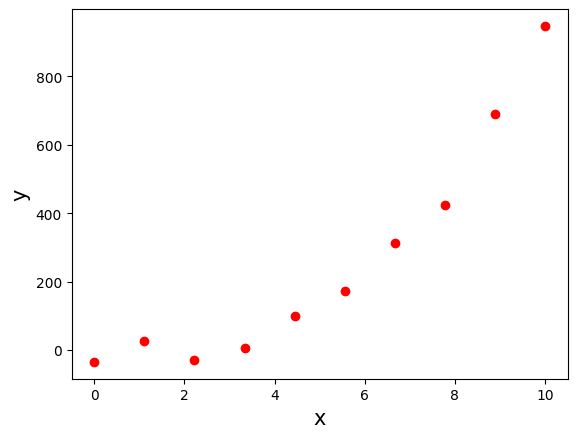

In [25]:
#codigo entregue pelo enunciado
N = 10
x = np.linspace(0,10,N)
y = x**3 + np.random.normal(0,50, N)
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

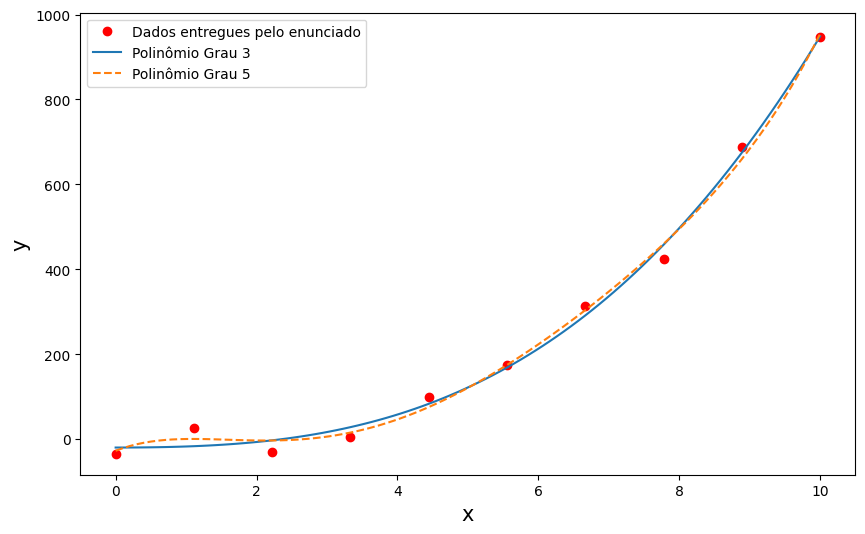

In [26]:
#esse np.polyfit irá retornar os coeficientes do polinomio e o np.poly1d vai criar uma função a partir desses coeficientes
grau3 = np.polyfit(x, y, 3)
p3 = np.poly1d(grau3)

grau5 = np.polyfit(x, y, 5)
p5 = np.poly1d(grau5)

y_pr3 = p3(x)
y_pr5 = p5(x)

#calculando os coeficientes R2
r2_grau3 = r2_score(y, y_pr3)
r2_grau5 = r2_score(y, y_pr5)

#Plotando o grafico------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='Dados entregues pelo enunciado')
x_plot = np.linspace(0, 10, 100)
plt.plot(x_plot, p3(x_plot), label=f'Polinômio Grau 3')
plt.plot(x_plot, p5(x_plot), '--', label=f'Polinômio Grau 5')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.show()

 2 - O que acontece com os coeficientes do modelo se normalizamos ou padronizarmos os dados?
 Faça uma análise usando dados do UCI: https://archive.ics.uci.edu/

In [50]:
#aqui vamos carregar o dataset Iris escolhido no UCI
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

#prever 'petal width (cm)' usando 3 colunas
y = X['petal width (cm)']
X_features = X.drop(columns=['petal width (cm)'])

#definição para pegar coeficiente
def pega_coef(X_data, y_data, scaler=None):

    if scaler:
        X_data = scaler.fit_transform(X_data)

    modelo = LinearRegression()
    modelo.fit(X_data, y_data)

    return modelo.coef_

# aqui obtemos coeficientes para diferentes cenarios
coef_original = pega_coef(X_features, y)
coef_stand = pega_coef(X_features, y, StandardScaler())
coef_norm = pega_coef(X_features, y, MinMaxScaler())

#aqui acontece a criação de um DataFrame para comparar
df_coefs = pd.DataFrame({
    'Originais': coef_original,
    'Padronizado(Standard)': coef_stand,
    'Normalizado(MinMax)': coef_norm
}, index=X_features.columns)

print("--------------------Coeficientes - Base Iris:--------------------------------")
print(df_coefs.round(4))

#Note que os coeficientes originais são muito diferentes dos que foram padronizados. Na escala original,
# o coeficiente é influenciado pelo valor absoluto dos centímetros. Quando padronizamos, todos estão na mesma unidade
#Note que na base Iris, o comprimento da pétala geralmente tem o coeficiente mais alto. Mas
# quando padronizamos confirma que ela é a variável com maior "peso" na predição, independentemente da escala original.

--------------------Coeficientes - Base Iris:--------------------------------
                   Originais  Padronizado(Standard)  Normalizado(MinMax)
sepal length (cm)    -0.2073                -0.1711              -0.7462
sepal width (cm)      0.2228                 0.0968               0.5348
petal length (cm)     0.5241                 0.9221               3.0921


3 - Os coeficientes do modelo medem a importância dos atributos? Elabore um experimento para analisar essa questão.

In [49]:
#primeiramente vamos criar os dados
np.random.seed(42)
N = 100
altura_m = np.random.uniform(0.5, 2.5, N)
nutrientes_mg = np.random.uniform(100, 5000, N)

#tem-se de ideia o alvo 'Saúde' onde a altura é 10x mais importante que os nutrientes
#Saude = 10 * Altura + 1 * Nutrientes + erro
y = (10 * altura_m) + (0.01 * nutrientes_mg) + np.random.normal(0, 5, N)

X = pd.DataFrame({'Altura_M': altura_m, 'Nutrientes_MG': nutrientes_mg})

#dados brutos
model_raw = LinearRegression().fit(X, y)

#dados padronizados com o z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model_scaled = LinearRegression().fit(X_scaled, y)

#mostra os coeficientes
print("--------------------- ORIGINAIS -------------------------------")
print(f"Altura: {model_raw.coef_[0]:.5f}")
print(f"Nutrientes: {model_raw.coef_[1]:.5f}")

print("\n------------- - PADRONIZADOS ---------------------------------")
print(f"Altura (com Z-score): {model_scaled.coef_[0]:.5f}")
print(f"Nutrientes (com Z-score): {model_scaled.coef_[1]:.5f}")

--------------------- ORIGINAIS -------------------------------
Altura: 9.14569
Nutrientes: 0.01073

------------- - PADRONIZADOS ---------------------------------
Altura (com Z-score): 5.41421
Nutrientes (com Z-score): 15.33937


4 -  Como predizer séries temporais usando modelos de regressão? Construa um exemplo.

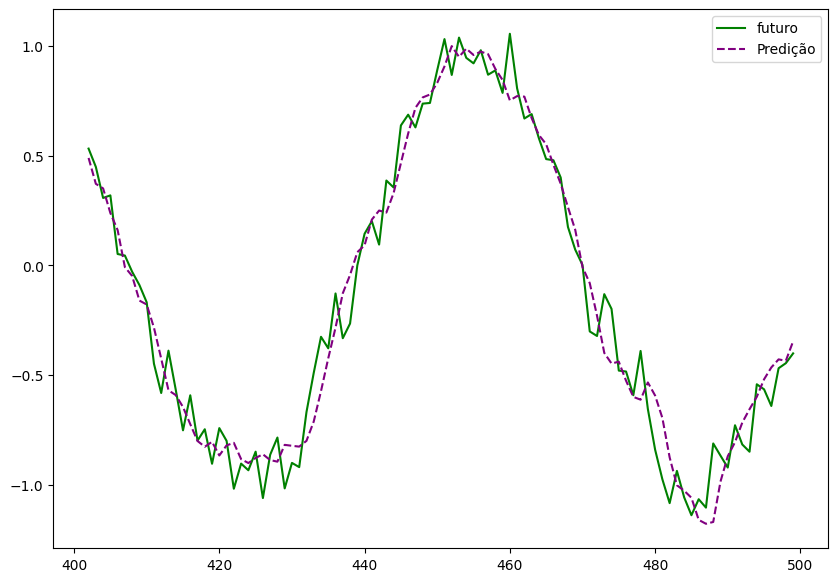

In [72]:
#primeiro vamos gerar uma série temporal sintetica
np.random.seed(42)
time = np.linspace(0, 50, 500)
series = np.sin(time) + np.random.normal(0, 0.1, 500)

#uma funçao para criar janelas
def criar_jan(data, tam_janela):
    df = pd.DataFrame(data, columns=['target'])

    for i in range(1, tam_janela + 1):
        df[f'lag_{i}'] = df['target'].shift(i)

    return df.dropna()

#vamos usar os ultimos 10 dias para prever o próximo
janela = 10
df_jan = criar_jan(series, janela)

#aqui acontece a separaçao entre treino e teste, lembrando que em series temporais nao pode ser aleatorio
split = int(len(df_jan) * 0.8)
train, test = df_jan.iloc[:split], df_jan.iloc[split:]
X_train = train.drop(columns=['target'])
y_train = train['target']
X_test = test.drop(columns=['target'])
y_test = test['target']

#treinamento
modelo = LinearRegression()
modelo.fit(X_train, y_train)

#predição
pred= modelo.predict(X_test)

#plotar o grafico
plt.figure(figsize=(10, 7))
plt.plot(test.index, y_test, label='futuro', color='green')
plt.plot(test.index, pred, label='Predição', color='purple', linestyle='--')
plt.legend()
plt.show()


5 - Selecione uma base de séries temporais da UCI e faça a predição.

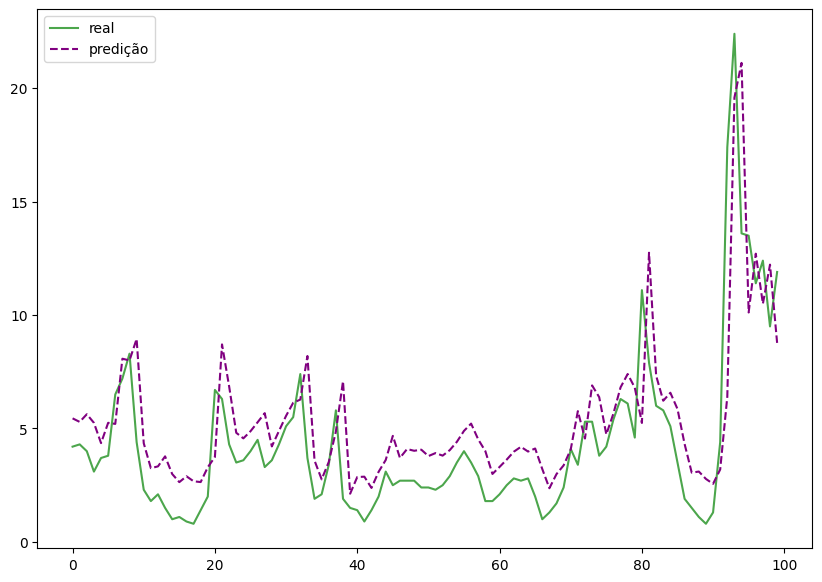

In [80]:
#pegando a base dessa forma pois diferente do database iris esse nao esta instalados em uma biblioteca
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
r = requests.get(url)

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    with z.open('AirQualityUCI.csv') as f:
        df = pd.read_csv(f, sep=';', decimal=',', encoding='utf-8')

#remove colunas fantasmas geradas
df = df.iloc[:, :15].dropna(how='all')

#aqui acontece o tratamento de valores nulos
df.replace(-200, np.nan, inplace=True)
target = 'C6H6(GT)'
df[target] = df[target].ffill()

#criançao de janelas
df['lag_1'] = df[target].shift(1)
df['lag_2'] = df[target].shift(2)
df_model = df[[target, 'lag_1', 'lag_2', 'T', 'RH']].dropna()

##aqui acontece a separaçao entre treino e teste, lembrando que em series temporais nao pode ser aleatorio
split = int(len(df_model) * 0.9)
train, test = df_model.iloc[:split], df_model.iloc[split:]

X_train, y_train = train.drop(columns=[target]), train[target]
X_test, y_test = test.drop(columns=[target]), test[target]

#modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = Ridge()
modelo.fit(X_train_scaled, y_train)
preds = modelo.predict(X_test_scaled)

#visualizar para auxiliar na clareza
plt.figure(figsize=(10, 7))
plt.plot(y_test.values[-100:], label='real', color='green', alpha=0.7)
plt.plot(preds[-100:], label='predição', color='purple', linestyle='--')
plt.legend()
plt.show()